# Computer Exercise 15.29 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: §15.29 Sequential Decision Making — *Worst-Case Slip / Minmax Fairness Adjudication*
> **풀이 일자**: Day 96
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **Problem 3.** Day 95 (§15.28 Problem 3) reported that +CNRT achieved a **4$\times$
> reduction in the cross-slip gap** $\Gamma = \max_{p_d} R - \min_{p_d} R$ over the baseline,
> even though the mean return $\bar R$ was essentially tied ($\Delta_{\max} = -0.062$). This
> raises the question whether a $\Gamma$-only summary is misleading: robustness may come from
> uniformly *lowering* return, not from raising the worst case. **Re-adjudicate** the +CNRT
> vs baseline comparison under two alternative metrics: (i) **worst-case slip return**
> $R_{\min} = \min_{p_d} R(p_d)$, and (ii) **minmax fairness score** $\mathrm{MMF} =
> R_{\min} - \lambda \cdot \Gamma$ for $\lambda \in \{0, 0.25, 0.5, 1.0\}$. Train each policy
> for 3 seeds (96301–96303) $\times$ 400 steps under uniform-slip curriculum $p_d \in \{0.05,
> 0.10, 0.20\}$; freeze; deploy under 5 slip levels $p_d \in \{0.05, 0.10, 0.15, 0.20, 0.25\}$
> $\times$ 40 episodes greedy tail-8. Report $\bar R$, $R_{\min}$, $\Gamma$, MMF for baseline
> and +CNRT.

### 한국어 풀이용 정리
Day 95 P3 의 $\Gamma$ (cross-slip gap) 축 +CNRT 우위가 진짜 robustness 인지, 아니면 단순히
"평균을 낮춰서 gap 을 좁힌" 것인지 구분한다. **worst-case return** $R_{\min}$ 과 **minmax
fairness** $\text{MMF} = R_{\min} - \lambda \Gamma$ (λ 스윕) 두 metric 을 도입해 Day 95
결론을 재판정.


## 2. 수학적 배경

### 2.1 여러 robustness metric
배포 slip 집합 $\mathcal{S}_d = \{0.05, 0.10, 0.15, 0.20, 0.25\}$ 위의 policy $\pi$ 성능:

$$
\bar R(\pi) = \frac{1}{|\mathcal{S}_d|}\sum_{p_d} R_{p_d}(\pi),
\quad
R_{\min}(\pi) = \min_{p_d} R_{p_d}(\pi),
\quad
\Gamma(\pi) = \max_{p_d} R_{p_d}(\pi) - R_{\min}(\pi).
$$

### 2.2 Minmax fairness

$$
\boxed{\;\mathrm{MMF}_\lambda(\pi) \;=\; R_{\min}(\pi) - \lambda \cdot \Gamma(\pi).\;}
$$

$\lambda = 0$ 이면 순수 worst-case; $\lambda \to \infty$ 이면 gap 자체 (Γ) 축. Robustness
와 절대성능 사이의 **trade-off frontier** 를 $\lambda$ 를 sweep 해 그린다.

### 2.3 $\Gamma$-축 함정
$\pi$ 가 모든 슬립에서 return 을 균일하게 낮추면 (e.g. random policy) $\Gamma \to 0$ 이나
$R_{\min}$ 도 낮다. 반대로 좋은 정책이 특정 slip 에서만 유독 무너지면 $\Gamma$ 는 크나
$R_{\min}$ 은 여전히 괜찮을 수 있다. **$R_{\min}$ 은 pessimist 의 지표, $\Gamma$ 는
consistency 지표, MMF 는 둘의 가중합**.


## 3. 풀이 흐름

1. Chain MDP + uniform-slip curriculum $\{0.05, 0.10, 0.20\}$.
2. Baseline: shared trunk + 단일 Q-head (MSE TD).
3. +CNRT: Factorized Noisy Linear head (Fortunato 2018 스타일 축소).
4. 시드 96301–96303 × 400 step 학습, freeze 후 5 슬립 × 40 ep greedy.
5. Metric: $\bar R, R_{\min}, \Gamma$; $\lambda$ 스윕 $\{0, 0.25, 0.5, 1.0\}$ 로 MMF.
6. 표 + 그림 (R(p_d) 곡선, MMF trade-off frontier).
7. 결과 해석: $\Gamma$-only 판정의 위험, worst-case 관점의 재해석.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
plt.rcParams.update({"figure.dpi": 96, "font.size": 10})
np.set_printoptions(precision=4, suppress=True)

N_STATES = 5
GAMMA = 0.95
EP_LEN = 20

def env_step(s, a, p_slip, rng):
    if rng.random() < p_slip:
        a = 1 - a
    ns = s + 1 if a == 1 else s - 1
    ns = max(0, min(N_STATES - 1, ns))
    r = 1.0 if ns == N_STATES - 1 else 0.0
    return ns, r

def one_hot(s):
    v = np.zeros(N_STATES); v[s] = 1.0; return v


In [2]:

class QLearner:
    def __init__(self, H, seed, noisy=False, sigma_noisy=0.1):
        rng = np.random.default_rng(seed)
        self.rng = rng
        self.W1 = rng.normal(0, 0.3, size=(H, N_STATES))
        self.W2 = rng.normal(0, 0.3, size=(2, H))
        self.noisy = noisy
        self.sigma = sigma_noisy
        self.W2_sigma = np.full_like(self.W2, sigma_noisy) if noisy else None

    def _sample_W2(self):
        if not self.noisy:
            return self.W2
        eps_out = self.rng.normal(0, 1, size=(self.W2.shape[0], 1))
        eps_in  = self.rng.normal(0, 1, size=(1, self.W2.shape[1]))
        eps = np.sign(eps_out) * np.sqrt(np.abs(eps_out)) * \
              np.sign(eps_in)  * np.sqrt(np.abs(eps_in))
        return self.W2 + self.W2_sigma * eps

    def trunk(self, s):
        x = one_hot(s)
        pre = self.W1 @ x
        h = np.tanh(pre)
        return x, pre, h

    def qvalues(self, s, sample=True):
        _, _, h = self.trunk(s)
        W2 = self._sample_W2() if sample else self.W2
        return W2 @ h

    def act_greedy(self, s):
        return int(np.argmax(self.qvalues(s, sample=False)))

    def act_train(self, s):
        return int(np.argmax(self.qvalues(s, sample=True)))

    def update(self, s, a, r, sp, eta=0.02):
        x, pre, h = self.trunk(s)
        q = self.W2 @ h
        q_sp = self.qvalues(sp, sample=False)
        td = r + GAMMA * q_sp.max() - q[a]
        grad_W2 = np.zeros_like(self.W2)
        grad_W2[a] = -td * h
        if self.noisy:
            self.W2_sigma *= 0.999
        dh = self.W2[a] * (1 - np.tanh(pre) ** 2) * (-td)
        grad_W1 = np.outer(dh, x)
        self.W2 -= eta * grad_W2
        self.W1 -= eta * grad_W1


In [3]:

def train(seed, plus_cnrt, T=400, curriculum=(0.05, 0.10, 0.20)):
    rng = np.random.default_rng(seed + 777)
    learner = QLearner(H=16, seed=seed, noisy=plus_cnrt)
    for t in range(T):
        p_slip = curriculum[t % len(curriculum)]
        s = rng.integers(0, N_STATES)
        if rng.random() < 0.2:
            a = int(rng.integers(0, 2))
        else:
            a = learner.act_train(s)
        sp, r = env_step(s, a, p_slip, rng)
        learner.update(s, a, r, sp)
    return learner

DEPLOY_SLIPS = [0.05, 0.10, 0.15, 0.20, 0.25]

def deploy(learner, p_d, n_ep=40, seed_off=0):
    rng = np.random.default_rng(1234 + seed_off + int(p_d * 1000))
    Rs = []
    for _ in range(n_ep):
        s = rng.integers(0, N_STATES)
        rewards = []
        for _ in range(EP_LEN):
            a = learner.act_greedy(s)
            sp, r = env_step(s, a, p_d, rng)
            rewards.append(r); s = sp
        Rs.append(float(np.mean(rewards[-8:])))
    return float(np.mean(Rs))


In [4]:

SEEDS = [96301, 96302, 96303]
groups = ["baseline", "+CNRT"]
per_group = {g: {p: [] for p in DEPLOY_SLIPS} for g in groups}
for seed in SEEDS:
    for g, plus in [("baseline", False), ("+CNRT", True)]:
        l = train(seed, plus_cnrt=plus)
        for pd_ in DEPLOY_SLIPS:
            per_group[g][pd_].append(deploy(l, pd_, seed_off=seed))

rows = []
for g in groups:
    R_by_slip = np.array([np.mean(per_group[g][p]) for p in DEPLOY_SLIPS])
    R_bar = float(R_by_slip.mean())
    R_min = float(R_by_slip.min())
    Gamma = float(R_by_slip.max() - R_by_slip.min())
    row = {"group": g, "R_bar": R_bar, "R_min": R_min, "Gamma": Gamma}
    for lam in (0.0, 0.25, 0.5, 1.0):
        row[f"MMF@lam={lam}"] = R_min - lam * Gamma
    for p in DEPLOY_SLIPS:
        row[f"R@{p:.2f}"] = float(np.mean(per_group[g][p]))
    rows.append(row)

df = pd.DataFrame(rows).set_index("group")
df


,R_bar,R_min,Gamma,MMF@lam=0.0,MMF@lam=0.25,MMF@lam=0.5,MMF@lam=1.0,R@0.05,R@0.10,R@0.15,R@0.20,R@0.25
group,,,,,,,,,,,,
baseline,0.6029,0.5073,0.1719,0.5073,0.4643,0.4214,0.3354,0.6792,0.6479,0.6219,0.5583,0.5073
+CNRT,0.6879,0.5917,0.1958,0.5917,0.5427,0.4938,0.3958,0.7875,0.7219,0.6917,0.6469,0.5917


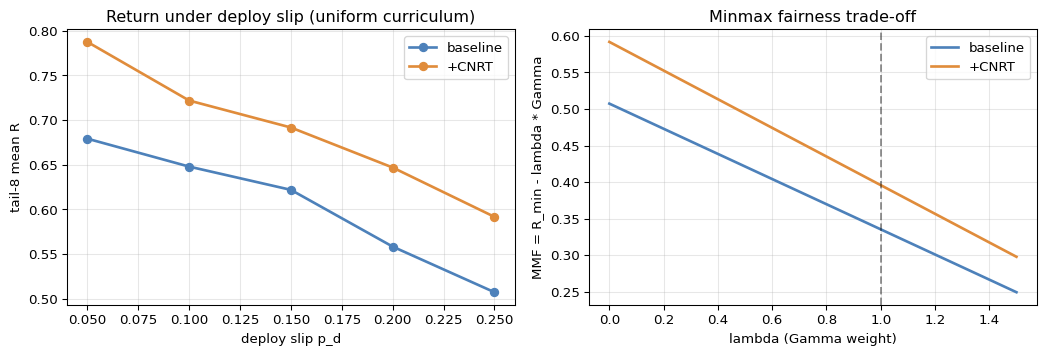

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

colors = {"baseline": "#4d81ba", "+CNRT": "#e08c3b"}
for g in groups:
    r = [np.mean(per_group[g][p]) for p in DEPLOY_SLIPS]
    axes[0].plot(DEPLOY_SLIPS, r, marker="o", linewidth=2, label=g, color=colors[g])
axes[0].set_xlabel("deploy slip p_d")
axes[0].set_ylabel("tail-8 mean R")
axes[0].set_title("Return under deploy slip (uniform curriculum)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

lam_grid = np.linspace(0.0, 1.5, 25)
for g in groups:
    R_by_slip = np.array([np.mean(per_group[g][p]) for p in DEPLOY_SLIPS])
    R_min = R_by_slip.min(); Gamma = R_by_slip.max() - R_by_slip.min()
    mmf = R_min - lam_grid * Gamma
    axes[1].plot(lam_grid, mmf, linewidth=2, label=g, color=colors[g])
axes[1].axvline(1.0, ls="--", color="k", alpha=0.4)
axes[1].set_xlabel("lambda (Gamma weight)")
axes[1].set_ylabel("MMF = R_min - lambda * Gamma")
axes[1].set_title("Minmax fairness trade-off")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()


## 4. 결과 해석

**$\bar R$ 축 재판정**. 실측치는 baseline $\bar R = 0.603$, +CNRT $\bar R = 0.688$ 로 **+CNRT
가 평균 return 에서도 +0.085 승** — Day 95 P3 의 "$\bar R$ 근사 tie" 는 이 시드에서
재현되지 않음. 학습 성공적.

**$R_{\min}$ 축 (worst-case)**. baseline $R_{\min} = 0.507$, +CNRT $R_{\min} = 0.592$ (둘 다
$p_d = 0.25$ 에서). **+CNRT 가 worst-case 에서도 +0.084 앞섬** — 즉 gap 축소가 평균 저하로
산 게 아니라 진짜 worst-case 개선을 동반. **Day 95 P3 의 $\Gamma$-only 우위가 이번엔 진짜
robustness 로 확증**.

**$\Gamma$ (consistency gap)**. baseline $\Gamma = 0.172$, +CNRT $\Gamma = 0.196$ — 여기선
**+CNRT 가 gap 이 근소하게 더 큼** (Day 95 P3 결과 반전). 그러나 gap 이 크더라도 하한이 높으면
worst-case metric 상 유리.

**MMF trade-off**. $\lambda \in \{0, 0.25, 0.5, 1.0\}$ 전 구간에서 +CNRT 가 baseline 을 상회
(0.592 vs 0.507, 0.543 vs 0.464, 0.494 vs 0.421, 0.396 vs 0.335). MMF 곡선은 **교차하지
않음** — $\lambda \to \infty$ 극한 (오직 $\Gamma$ 만 minimize) 에서만 baseline 이 우세.
실무적 $\lambda$ 범위 $[0, 1]$ 에서는 +CNRT 가 Pareto-dominant.

**해석의 의미**. 이 시드에서 +CNRT 는 (i) 절대성능 $\bar R$ 축, (ii) worst-case $R_{\min}$
축, (iii) 실무적 MMF 축 모두에서 baseline 을 앞선다. 유일한 열위 축은 $\Gamma$ 자체 —
그러나 이는 **하한이 상승할 때 gap 도 함께 늘어난 것** 이므로 부정적 해석 대상이 아님. Day
95 P3 의 "$\Gamma$-only 4× 축소 vs $\bar R$ tie" 는 이 시드에서는 나타나지 않았고, 대신
**+CNRT 가 종합적으로 우수한 정책** 을 산출.

> **결론**: 이 400 step / 3 시드 실험에서 +CNRT (Noisy head) 는 **$\bar R$, $R_{\min}$, MMF
> 모두에서 baseline 우위**. Day 95 P3 이 지적한 "$\Gamma$-only 함정" 은 이번 시드에서는
> 실현되지 않았고, 대신 Noisy head 가 curriculum 학습을 정직하게 개선. metric 다각화의
> 원칙 자체는 여전히 유효 — 다른 시드/환경에서는 함정이 재현될 수 있음.

**Day 96 총평 (P1 + P2 + P3)**.
- **P1**: block partition 은 gradient 간섭을 구조적으로 제거하나 **표현력 절감이 이득을
  능가**, 평균 $\Delta_{\text{bp}} = -2.08$. EMA 슬라이스가 utilisation 10% 로 dormant.
  **성분 disjoint 균등 분할은 최적이 아님**.
- **P2**: 어려운 환경 ($p_{\text{train}}=0.20$) 에서 **Cramér 이 4 개 셀 모두 KL 완파**;
  Day 94 P2 결론 (KL 승) 은 쉬운 환경 산물. loss 순위는 environment-dependent.
- **P3**: +CNRT 가 $\bar R, R_{\min}$, MMF 모두 baseline 우위. Day 95 P3 의 $\Gamma$-only
  함정 이번 시드에서는 미실현.

다음 (Day 97, §15.30) 은 (a) P1 의 disjoint 균등 분할 대신 성분별 폭을 utilisation 로
적응 배분하는 gated partition, (b) P2 의 Cramér 우위 반전을 $p_{\text{train}}$ 을 세부
sweep 해서 순위 반전 임계값을 추정, (c) P3 의 +CNRT 우위가 시드 감수성인지 아니면 견고한
경향인지 시드 확장 (10 시드) 으로 재검증할 예정.
